Vaishnavi Sawant

23102A0063

CMPN - A

# Social Network Analysis with R

### R Programming Laboratory

**Aim:**  
To implement Social Network Analysis using R by representing entities as nodes
and relationships as edges, analyzing network characteristics, identifying
important/influential nodes, visualizing the network, and interpreting the results.

## Problem Statement

The objective is to study Social Network Analysis using R and implement the
network-analysis workflow demonstrated in the prescribed tutorial.

The analysis represents entities as nodes/vertices and relationships as
edges/links. The network is then analyzed to understand its structure,
identify important or influential nodes, generate visualizations, and
interpret the obtained results.

Install required packages

In [1]:
install.packages("igraph", repos = "https://cloud.r-project.org")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(igraph)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [3]:
install.packages(c("igraph", "ggplot2"),
                 repos = "https://cloud.r-project.org")

library(igraph)
library(ggplot2)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
cat("R Version:", R.version.string, "\n")

R Version: R version 4.6.1 (2026-06-24) 


## Dataset Loading

The dataset used for the Social Network Analysis is the `networkdata.csv`
dataset provided in the GitHub repository associated with the prescribed
tutorial.

In [5]:
data <- read.csv(
  "https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv",
  header = TRUE
)

head(data)

,first,second,grade,spec
,<chr>,<chr>,<int>,<chr>
1,AA,DD,6,Y
2,AB,DD,6,R
3,AF,BA,6,Q
4,DD,DA,6,Q
5,CD,EC,6,X
6,DD,CE,6,Y


In [6]:
str(data)

'data.frame':	290 obs. of  4 variables:
 $ first : chr  "AA" "AB" "AF" "DD" ...
 $ second: chr  "DD" "DD" "BA" "DA" ...
 $ grade : int  6 6 6 6 6 6 6 6 6 6 ...
 $ spec  : chr  "Y" "R" "Q" "Q" ...


In [7]:
dim(data)

[1] 290   4

In [8]:
names(data)

[1] "first"  "second" "grade"  "spec"

In [10]:
head(data$first)

[1] "AA" "AB" "AF" "DD" "CD" "DD"

In [11]:
head(data$second)

[1] "DD" "DD" "BA" "DA" "EC" "CE"

Check for missing values

In [12]:
sum(is.na(data))

[1] 0

In [13]:
sum(is.na(data$first))
sum(is.na(data$second))

[1] 0

[1] 0

Check the data types

In [14]:
class(data$first)
class(data$second)
str(data)

[1] "character"

[1] "character"

'data.frame':	290 obs. of  4 variables:
 $ first : chr  "AA" "AB" "AF" "DD" ...
 $ second: chr  "DD" "DD" "BA" "DA" ...
 $ grade : int  6 6 6 6 6 6 6 6 6 6 ...
 $ spec  : chr  "Y" "R" "Q" "Q" ...


Create the edge-list data frame

In [16]:
y <- data.frame(data$first, data$second)

head(y)

,data.first,data.second
,<chr>,<chr>
1,AA,DD
2,AB,DD
3,AF,BA
4,DD,DA
5,CD,EC
6,DD,CE


In [17]:
names(y) <- c("from", "to")

head(y)

,from,to
,<chr>,<chr>
1,AA,DD
2,AB,DD
3,AF,BA
4,DD,DA
5,CD,EC
6,DD,CE


Load igraph

In [18]:
library(igraph)

Create the network

In [20]:
net <- graph.data.frame(y, directed = TRUE)

net

Warning message:
“`graph.data.frame()` was deprecated in igraph 2.0.0.
ℹ Please use `graph_from_data_frame()` instead.”


IGRAPH 867445e DN-- 52 290 -- 
+ attr: name (v/c)
+ edges from 867445e (vertex names):
 [1] AA->DD AB->DD AF->BA DD->DA CD->EC DD->CE CD->FA CD->CC BA->AF CB->CA
[11] CC->CA CD->CA BC->CA DD->DA ED->AD AE->AC AB->BA CD->EC CA->CC EB->CC
[21] BF->CE BB->CD AC->AE CC->FB DC->BB BD->CF DB->DA DD->DA DB->DD BC->AF
[31] CF->DE DF->BF CB->CA BE->CA EA->CA CB->CA CB->CA CC->CA CD->CA BC->CA
[41] BF->CA CE->CA AC->AD BD->BE AE->DF CB->DF AC->DF AA->DD AA->DD AA->DD
[51] CD->DD AA->DD EE->DD CD->DD DB->AA AA->FC BE->CC EF->FD CF->FE BB->DD
[61] CD->DD BA->AB CD->EC BE->EE CE->CC CD->CC ED->CC BB->CC BE->CE DD->CE
[71] AC->CD ED->CD FF->CD AC->CD DD->CD DD->CD AE->GA AE->GA AE->GA AE->GA
+ ... omitted several edges

represent entities as nodes

represent relationships as edges

In [23]:
cat("Number of Nodes:", vcount(net), "\n")
cat("Number of Edges:", ecount(net), "\n")

Number of Nodes: 52 
Number of Edges: 290 


Inspect the nodes

In [24]:
V(net)

+ 52/52 vertices, named, from 867445e:
 [1] AA AB AF DD CD BA CB CC BC ED AE CA EB BF BB AC DC BD DB CF DF BE EA CE EE
[26] EF FF FD GB GC GD AD KA KF LC DA EC FA FB DE FC FE GA GE KB KC KD KE LB LA
[51] LD LE

In [25]:
V(net)$name

[1] "AA" "AB" "AF" "DD" "CD" "BA" "CB" "CC" "BC" "ED" "AE" "CA" "EB" "BF" "BB"
[16] "AC" "DC" "BD" "DB" "CF" "DF" "BE" "EA" "CE" "EE" "EF" "FF" "FD" "GB" "GC"
[31] "GD" "AD" "KA" "KF" "LC" "DA" "EC" "FA" "FB" "DE" "FC" "FE" "GA" "GE" "KB"
[46] "KC" "KD" "KE" "LB" "LA" "LD" "LE"

Inspect the edges

In [26]:
E(net)

+ 290/290 edges from 867445e (vertex names):
  [1] AA->DD AB->DD AF->BA DD->DA CD->EC DD->CE CD->FA CD->CC BA->AF CB->CA
 [11] CC->CA CD->CA BC->CA DD->DA ED->AD AE->AC AB->BA CD->EC CA->CC EB->CC
 [21] BF->CE BB->CD AC->AE CC->FB DC->BB BD->CF DB->DA DD->DA DB->DD BC->AF
 [31] CF->DE DF->BF CB->CA BE->CA EA->CA CB->CA CB->CA CC->CA CD->CA BC->CA
 [41] BF->CA CE->CA AC->AD BD->BE AE->DF CB->DF AC->DF AA->DD AA->DD AA->DD
 [51] CD->DD AA->DD EE->DD CD->DD DB->AA AA->FC BE->CC EF->FD CF->FE BB->DD
 [61] CD->DD BA->AB CD->EC BE->EE CE->CC CD->CC ED->CC BB->CC BE->CE DD->CE
 [71] AC->CD ED->CD FF->CD AC->CD DD->CD DD->CD AE->GA AE->GA AE->GA AE->GA
 [81] BA->ED BE->ED EB->ED CD->ED FD->EF FD->EF CD->BB BF->BB BC->BB BB->CF
 [91] AE->AC DD->DA BE->CA BE->CA CB->CA CB->CA CC->CA BE->CC BE->CC DB->DD
+ ... omitted several edges

In [27]:
as_data_frame(net, what = "edges")

,from,to
,<chr>,<chr>
1,AA,DD
2,AB,DD
3,AF,BA
4,DD,DA
5,CD,EC
6,DD,CE
7,CD,FA
8,CD,CC
9,BA,AF


## Network visualization

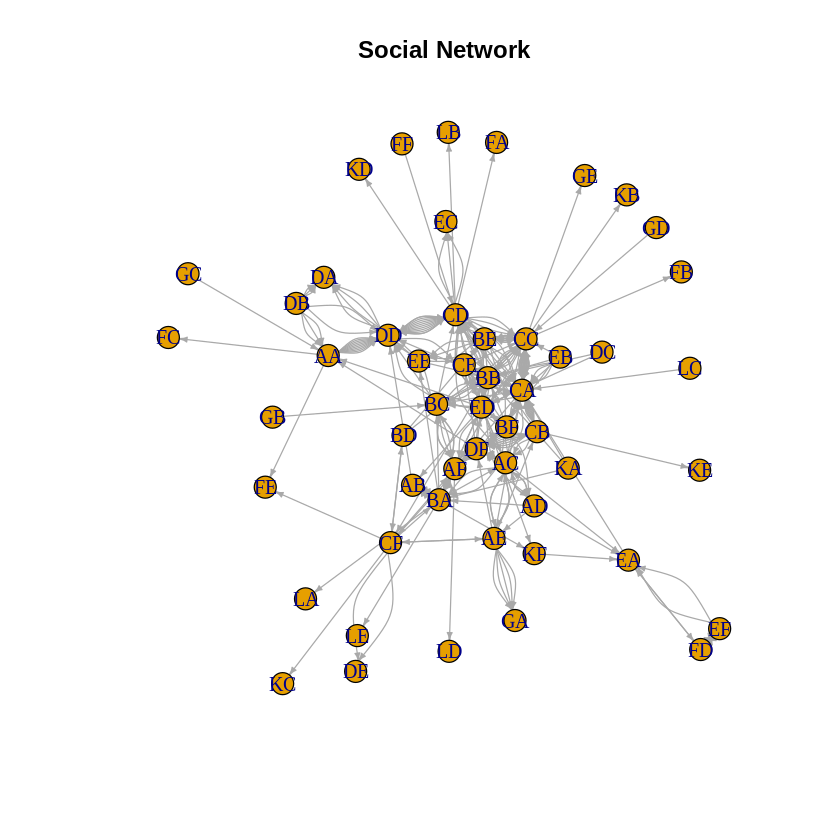

In [29]:
plot(
  net,
  vertex.label = V(net)$name,
  vertex.size = 8,
  edge.arrow.size = 0.3,
  main = "Social Network"
)

## Node Degree Analysis

In [30]:
V(net)$label <- V(net)$name

V(net)$degree <- degree(net)

head(V(net)$degree)

[1] 18  9 23 36 40 26

In [31]:
degree_values <- degree(net, mode = "all")

degree_table <- data.frame(
  Node = names(degree_values),
  Degree = as.numeric(degree_values)
)

degree_table

Node,Degree
<chr>,<dbl>
AA,18
AB,9
AF,23
DD,36
CD,40
BA,26
CB,24
CC,50
BC,21


Sort nodes by degree

In [32]:
degree_table_sorted <- degree_table[
  order(-degree_table$Degree),
]

degree_table_sorted

,Node,Degree
,<chr>,<dbl>
12,CA,62
8,CC,50
5,CD,40
4,DD,36
10,ED,27
16,AC,27
6,BA,26
7,CB,24
3,AF,23


Finding the most connected node

In [33]:
most_connected <- degree_table_sorted[1, ]

cat("Most connected node:", most_connected$Node, "\n")
cat("Degree:", most_connected$Degree, "\n")

Most connected node: CA 
Degree: 62 


In-degree and out-degree

In [34]:
in_degree <- degree(net, mode = "in")
out_degree <- degree(net, mode = "out")
total_degree <- degree(net, mode = "all")

degree_analysis <- data.frame(
  Node = V(net)$name,
  In_Degree = as.numeric(in_degree),
  Out_Degree = as.numeric(out_degree),
  Total_Degree = as.numeric(total_degree)
)

degree_analysis

Node,In_Degree,Out_Degree,Total_Degree
<chr>,<dbl>,<dbl>,<dbl>
AA,6,12,18
AB,3,6,9
AF,16,7,23
DD,28,8,36
CD,15,25,40
BA,13,13,26
CB,2,22,24
CC,25,25,50
BC,7,14,21


Finding highest in-degree and out-degree

In [35]:
highest_in <- degree_analysis[
  which.max(degree_analysis$In_Degree),
]

highest_out <- degree_analysis[
  which.max(degree_analysis$Out_Degree),
]

cat("Highest In-Degree Node:", highest_in$Node,
    "| In-Degree:", highest_in$In_Degree, "\n")

cat("Highest Out-Degree Node:", highest_out$Node,
    "| Out-Degree:", highest_out$Out_Degree, "\n")

Highest In-Degree Node: CA | In-Degree: 50 
Highest Out-Degree Node: CD | Out-Degree: 25 


## Histogram of Node Degree

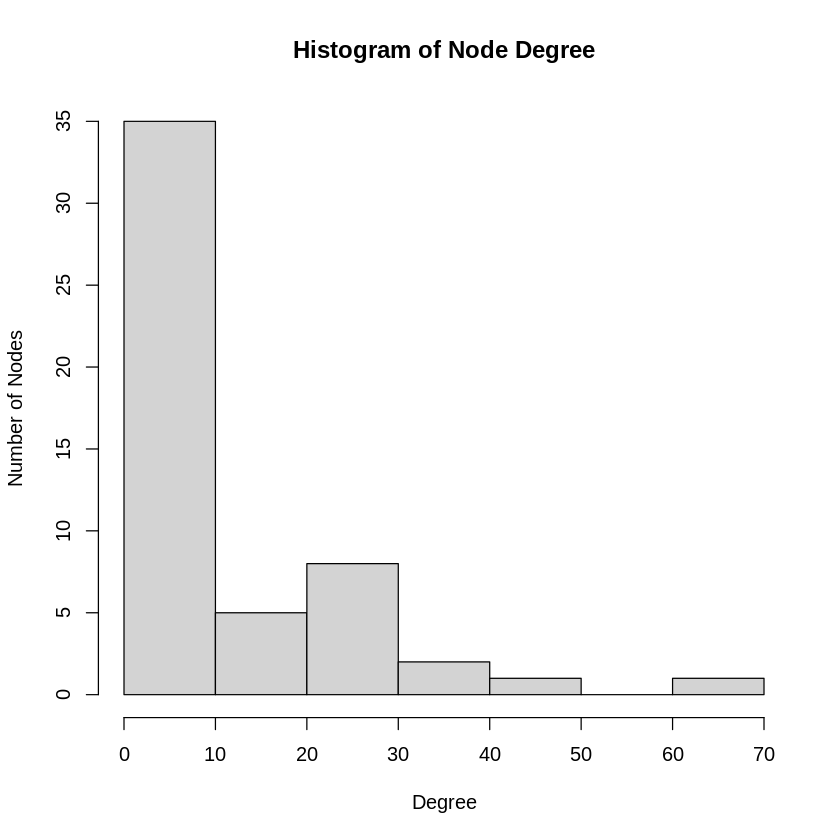

In [36]:
hist(
  V(net)$degree,
  main = "Histogram of Node Degree",
  xlab = "Degree",
  ylab = "Number of Nodes"
)

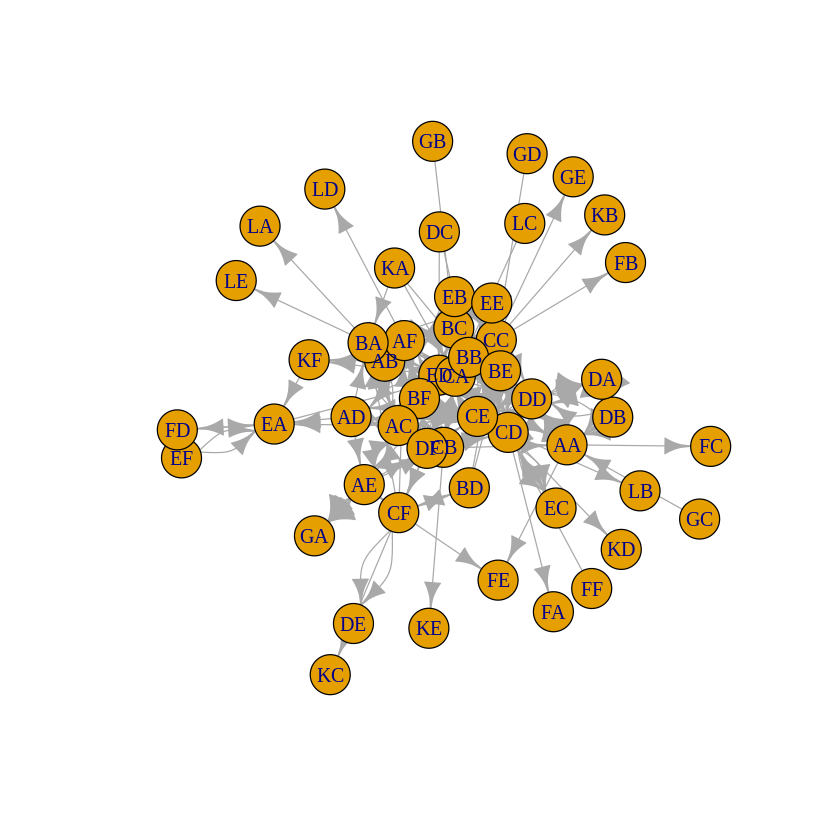

In [37]:
plot(net)

Highlight degree using node size

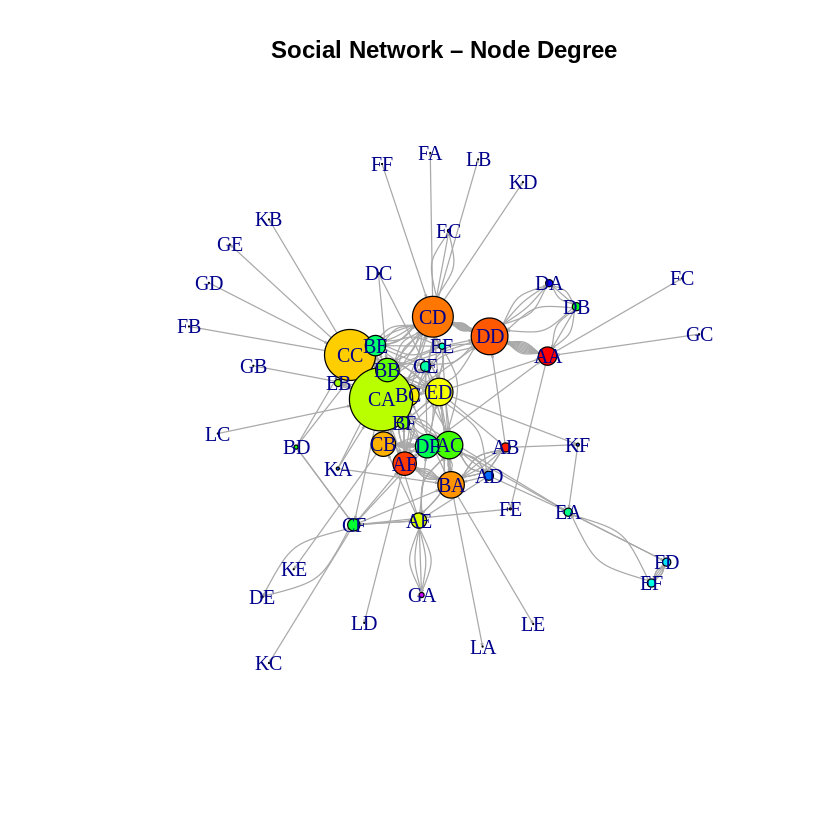

In [38]:
plot(
  net,
  vertex.color = rainbow(vcount(net)),
  vertex.size = V(net)$degree * 0.4,
  vertex.label = V(net)$name,
  edge.arrow.size = 0.1,
  layout = layout.fruchterman.reingold,
  main = "Social Network – Node Degree"
)

Calculate network diameter

In [39]:
network_diameter <- diameter(
  net,
  directed = FALSE,
  weights = NA
)

cat("Network Diameter:", network_diameter, "\n")

Network Diameter: 5 


Calculate edge density

In [40]:
network_density <- edge_density(
  net,
  loops = FALSE
)

cat("Network Edge Density:", network_density, "\n")

Network Edge Density: 0.1093514 


In [41]:
manual_density <- ecount(net) /
  (vcount(net) * (vcount(net) - 1))

cat("Manual Density:", manual_density, "\n")

Manual Density: 0.1093514 


Calculate reciprocity

In [42]:
network_reciprocity <- reciprocity(net)

cat("Network Reciprocity:", network_reciprocity, "\n")

Network Reciprocity: 0.2965517 


Calculate closeness centrality

In [43]:
closeness_values <- closeness(
  net,
  mode = "all",
  weights = NA
)

closeness_table <- data.frame(
  Node = names(closeness_values),
  Closeness = as.numeric(closeness_values)
)

closeness_table_sorted <- closeness_table[
  order(-closeness_table$Closeness),
]

closeness_table_sorted

,Node,Closeness
,<chr>,<dbl>
10,ED,0.010638298
15,BB,0.010204082
5,CD,0.010101010
12,CA,0.010000000
8,CC,0.009708738
3,AF,0.009433962
16,AC,0.009433962
9,BC,0.009259259
6,BA,0.009174312


In [44]:
top_closeness <- closeness_table_sorted[1, ]

cat(
  "Highest Closeness Node:",
  top_closeness$Node,
  "\nCloseness:",
  top_closeness$Closeness
)

Highest Closeness Node: ED 
Closeness: 0.0106383

Calculate betweenness centrality

In [45]:
betweenness_values <- betweenness(
  net,
  directed = TRUE,
  weights = NA
)

betweenness_table <- data.frame(
  Node = names(betweenness_values),
  Betweenness = as.numeric(betweenness_values)
)

betweenness_table_sorted <- betweenness_table[
  order(-betweenness_table$Betweenness),
]

betweenness_table_sorted

,Node,Betweenness
,<chr>,<dbl>
5,CD,375.992047
10,ED,343.016093
12,CA,292.157605
15,BB,244.963181
8,CC,225.269107
6,BA,184.496219
23,EA,183.604022
20,CF,181.814414
16,AC,172.427422


In [46]:
top_betweenness <- betweenness_table_sorted[1, ]

cat(
  "Highest Betweenness Node:",
  top_betweenness$Node,
  "\nBetweenness:",
  top_betweenness$Betweenness
)

Highest Betweenness Node: CD 
Betweenness: 375.992

Edge betweenness

In [47]:
edge_betweenness_values <- edge_betweenness(
  net,
  directed = TRUE,
  weights = NA
)

edge_betweenness_values

[1]   8.2707602  12.2696596  28.6724608   8.5000000  11.6666667   9.5384778
  [7]  35.0000000  10.3117615   2.1678161   0.8452815   1.0257502   6.6590740
 [13]   3.4630746   8.5000000  38.3424761   9.9594327   6.7073708  11.6666667
 [19]  15.6173930   5.6428571   3.0335576   7.9854978  23.2877711  35.0000000
 [25]  16.5071429  15.8110766   0.3333333   8.5000000  19.5000000   4.7249872
 [31]  17.5000000   1.6302691   0.8452815   1.2060041 159.6040215   0.8452815
 [37]   0.8452815   1.0257502   6.6590740   3.4630746   3.0739106  21.1262561
 [43]   3.1559524  19.5795644  11.9135326   1.6610221  26.6141540   8.2707602
 [49]   8.2707602   8.2707602   2.6400345   8.2707602   6.5543478   2.6400345
 [55]   1.0000000  35.0000000   1.4545455   0.5000000  21.5113636  14.9311391
 [61]   2.6400345  10.0266935  11.6666667   7.3782674  32.8170909  10.3117615
 [67]   8.6926601   4.2483254   2.6300193   9.5384778  15.2423634   6.3378041
 [73]  43.0000000  15.2423634  75.9568420  75.9568420   7.0000000   7.0000000
 [79]   7.0000000   7.0000000  31.7889050  44.9694224  11.4053641  77.8116698
 [85]   8.5000000   8.5000000  41.4031682  17.8912973  22.7518057 170.5570912
 [91]   9.9594327   8.5000000   1.2060041   1.2060041   0.8452815   0.8452815
 [97]   1.0257502   1.4545455   1.4545455  19.5000000   8.6699440   6.3378041
[103]   6.3378041   7.9854978  24.1492773   5.2777778   4.9642857   8.1531958
[109]   4.7249872  43.0000000  10.6492436  10.6492436   9.0963664   6.7073708
[115]  61.9759699   1.0000000  14.2631579  43.0000000   7.3449678   9.4463552
[121]   3.0739106   1.0257502   3.4567812  12.2337252   0.8452815   1.0257502
[127]   3.1559524  28.6724608  28.6724608  13.8856488  18.8332195  18.8332195
[133]  18.8332195   1.6610221   1.6610221   1.6610221   8.2707602   8.2707602
[139]   8.2707602   2.6400345   2.6400345   8.2707602   5.0425151   1.0000000
[145]  66.0000000   0.5000000  35.0000000   8.2707602   7.3782674   7.3782674
[151]  43.0000000   4.2483254  15.6173930  10.3117615  15.6173930   4.2483254
[157]   3.1317588   6.6082814   7.0000000  26.4928571  43.8927787  77.8116698
[163]  38.4100190  13.0280429  35.0000000  31.9655162  20.5000000  35.0000000
[169]  39.4477896  61.2789626  22.7518057  35.0000000  15.7805755   3.1931624
[175]   3.1931624  79.9409767   7.6666667   6.4839002   0.8452815   1.0257502
[181]   1.8212121   1.4545455   8.6699440  10.7774241  35.0000000  18.5113473
[187]   7.4655914   2.1678161  27.0527324  57.9965713   4.7249872   5.4186779
[193]   9.0963664   1.6302691  40.7648504   0.8452815   3.4567812   1.0257502
[199]   1.0257502   1.0257502   1.0257502   1.8212121   3.4630746   0.8452815
[205]   1.0257502   1.8212121  38.3424761  11.5478831  17.8500000  22.2077698
[211]   6.7073708   1.6610221   1.6610221  26.6141540   2.6400345   2.6400345
[217]   2.6400345   5.0425151   5.0425151  13.4886364  15.8673354   4.2483254
[223]  15.6173930  97.3426390  11.4053641   8.5000000  41.0000000  20.5000000
[229]  59.2291344  22.7518057  52.5217258  65.5932804   5.7675522   5.7675522
[235]   0.8452815   3.4567812   1.0257502   1.0257502   1.0257502  12.5754738
[241]   1.4545455   8.6926601  15.6173930  10.3117615   2.6400345   5.3008547
[247]   2.1678161   2.1678161   5.2777778   4.7249872  12.3542305  23.3750082
[253]  23.3750082  17.5000000  62.9330808   1.6302691   1.0257502   1.0257502
[259]   1.0257502  35.8509676   6.7073708  35.0000000  35.0000000   4.2483254
[265]   4.8544928   6.6082814  43.7635430   8.5000000  17.4833333   7.6132916
[271]   9.0827783  13.6656706   8.3332726   3.1931624   3.1931624   0.3333333
[277]   0.3333333  43.0000000   2.1678161  39.9661148  35.0000000  30.8169125
[283]  23.2877711  44.4093709  17.7160533   8.3332726   2.6400345  35.0000000
[289]  10.0266935   1.6610221

Creating a combined network-measures table

In [48]:
network_summary <- data.frame(
  Node = V(net)$name,
  Degree = as.numeric(degree(net, mode = "all")),
  In_Degree = as.numeric(degree(net, mode = "in")),
  Out_Degree = as.numeric(degree(net, mode = "out")),
  Closeness = as.numeric(closeness(net, mode = "all", weights = NA)),
  Betweenness = as.numeric(betweenness(net, directed = TRUE, weights = NA))
)

network_summary

Node,Degree,In_Degree,Out_Degree,Closeness,Betweenness
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AA,18,6,12,0.008196721,89.196239
AB,9,3,6,0.007936508,4.564734
AF,23,16,7,0.009433962,109.762225
DD,36,28,8,0.008771930,162.990640
CD,40,15,25,0.010101010,375.992047
BA,26,13,13,0.009174312,184.496219
CB,24,2,22,0.008474576,36.237779
CC,50,25,25,0.009708738,225.269107
BC,21,7,14,0.009259259,94.821412


Then sorting it by degree

In [49]:
network_summary[
  order(-network_summary$Degree),
]

,Node,Degree,In_Degree,Out_Degree,Closeness,Betweenness
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12,CA,62,50,12,0.010000000,292.157605
8,CC,50,25,25,0.009708738,225.269107
5,CD,40,15,25,0.010101010,375.992047
4,DD,36,28,8,0.008771930,162.990640
10,ED,27,10,17,0.010638298,343.016093
16,AC,27,12,15,0.009433962,172.427422
6,BA,26,13,13,0.009174312,184.496219
7,CB,24,2,22,0.008474576,36.237779
3,AF,23,16,7,0.009433962,109.762225


Hub and authority scores

In [50]:
hs <- hub_score(net)$vector
auth <- authority.score(net)$vector

Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”
Warning message:
“`authority.score()` was deprecated in igraph 2.0.0.
ℹ Please use `hits_scores()` instead.”


In [51]:
hub_table <- data.frame(
  Node = names(hs),
  Hub_Score = as.numeric(hs)
)

hub_table <- hub_table[
  order(-hub_table$Hub_Score),
]

hub_table

,Node,Hub_Score
,<chr>,<dbl>
8,CC,1.0000000000
7,CB,0.7145888159
5,CD,0.2350165253
9,BC,0.2321828382
22,BE,0.2195271464
16,AC,0.2093517929
13,EB,0.1870058122
14,BF,0.1272314500
15,BB,0.1150808240


In [52]:
authority_table <- data.frame(
  Node = names(auth),
  Authority_Score = as.numeric(auth)
)

authority_table <- authority_table[
  order(-authority_table$Authority_Score),
]

authority_table

,Node,Authority_Score
,<chr>,<dbl>
12,CA,1.000000e+00
21,DF,1.925650e-01
4,DD,1.409698e-01
8,CC,1.121941e-01
22,BE,1.095155e-01
3,AF,8.375004e-02
15,BB,8.323026e-02
5,CD,7.894656e-02
16,AC,6.262068e-02


Top hub

In [53]:
top_hub <- hub_table[1, ]

cat(
  "Top Hub Node:",
  top_hub$Node,
  "\nHub Score:",
  top_hub$Hub_Score
)

Top Hub Node: CC 
Hub Score: 1

Top authority

In [54]:
top_authority <- authority_table[1, ]

cat(
  "Top Authority Node:",
  top_authority$Node,
  "\nAuthority Score:",
  top_authority$Authority_Score
)

Top Authority Node: CA 
Authority Score: 1

Hub visualization

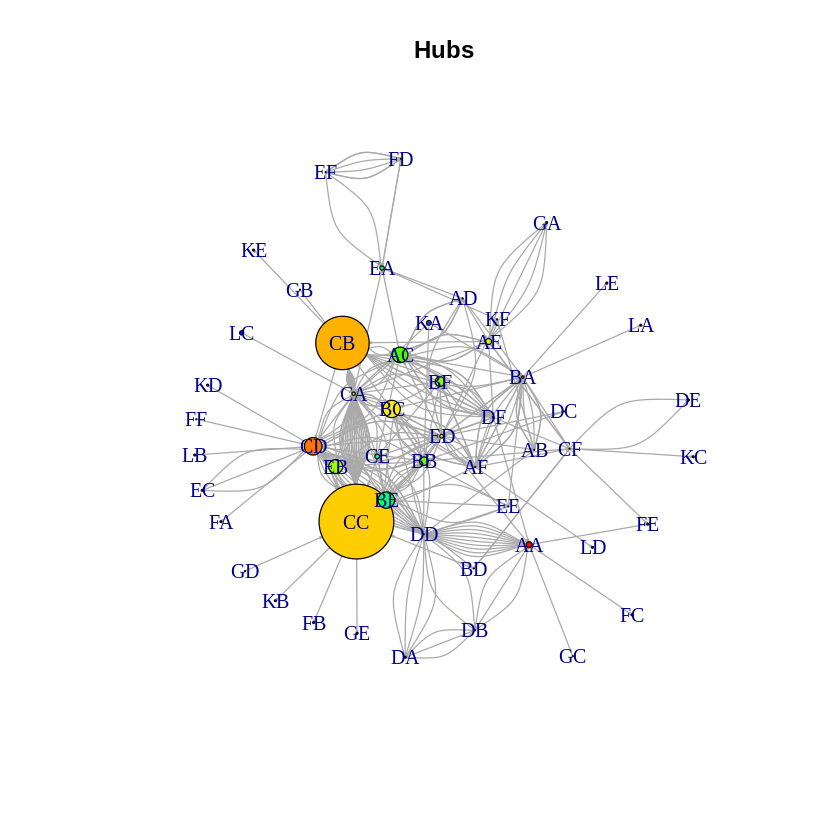

In [55]:
set.seed(123)

plot(
  net,
  vertex.size = hs * 30,
  vertex.label = V(net)$name,
  vertex.color = rainbow(vcount(net)),
  main = "Hubs",
  edge.arrow.size = 0.1,
  layout = layout.kamada.kawai
)

Authority visualization

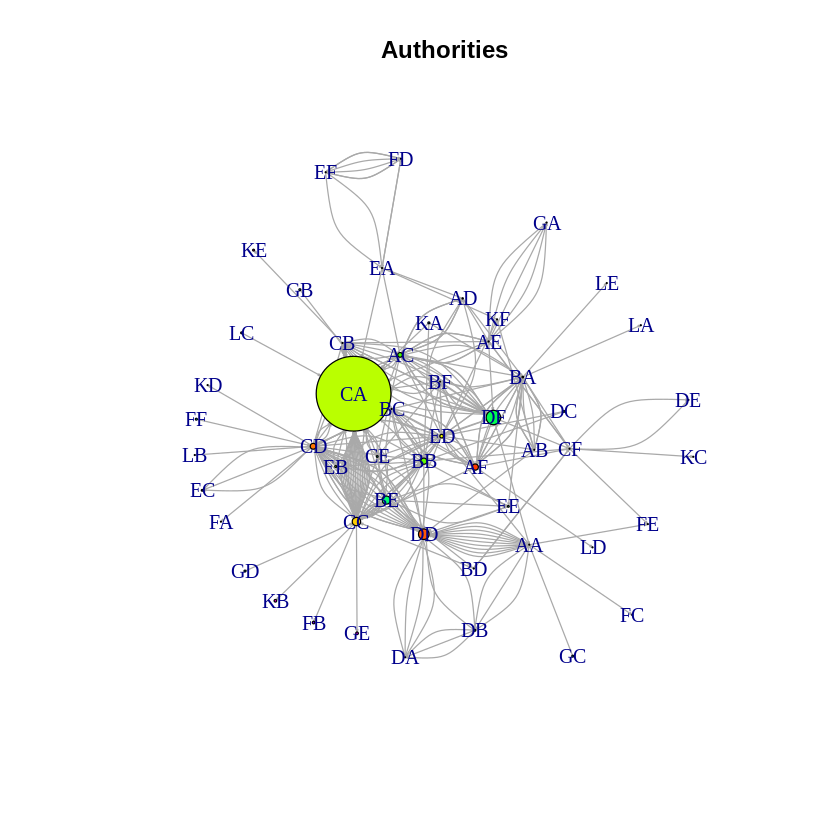

In [56]:
set.seed(123)

plot(
  net,
  vertex.size = auth * 30,
  vertex.label = V(net)$name,
  vertex.color = rainbow(vcount(net)),
  main = "Authorities",
  edge.arrow.size = 0.1,
  layout = layout.kamada.kawai
)

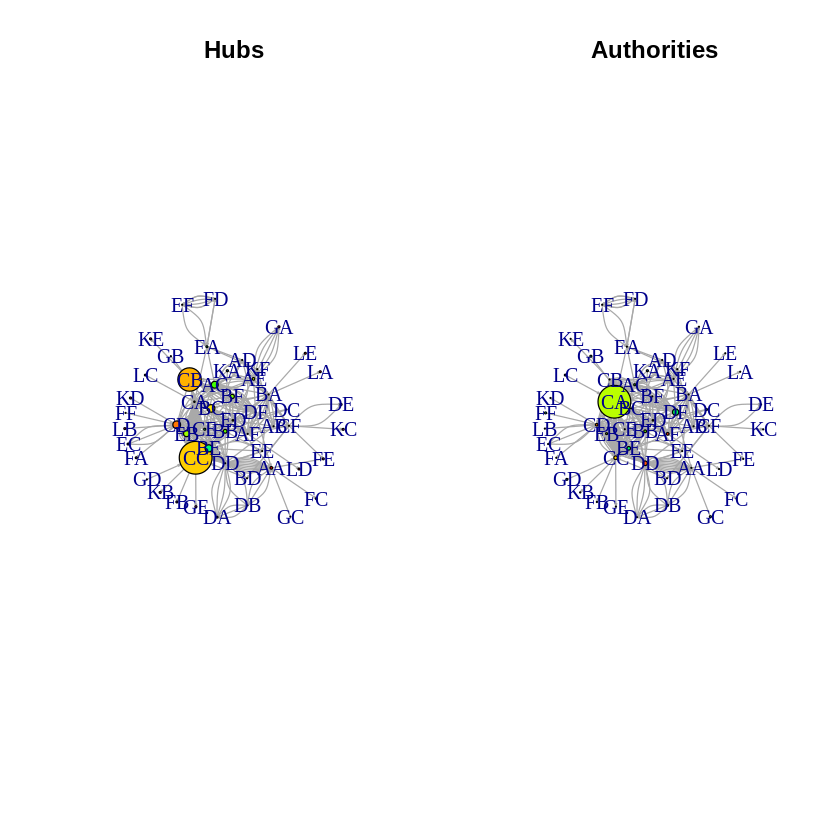

In [57]:
par(mfrow = c(1, 2))

set.seed(123)

plot(
  net,
  vertex.size = hs * 30,
  vertex.label = V(net)$name,
  vertex.color = rainbow(vcount(net)),
  main = "Hubs",
  edge.arrow.size = 0.1,
  layout = layout.kamada.kawai
)

plot(
  net,
  vertex.size = auth * 30,
  vertex.label = V(net)$name,
  vertex.color = rainbow(vcount(net)),
  main = "Authorities",
  edge.arrow.size = 0.1,
  layout = layout.kamada.kawai
)

par(mfrow = c(1, 1))

Community Detection

In [58]:
community_net <- graph.data.frame(
  y,
  directed = FALSE
)

In [69]:
cnet <- cluster_edge_betweenness(
  community_net
)

In [60]:
cnet

IGRAPH clustering edge betweenness, groups: 26, mod: 0.35
+ groups:
  $`1`
  [1] "AA" "DD" "CD" "ED" "DB" "DA" "EC"
  
  $`2`
  [1] "AB" "AF" "BA" "BC"
  
  $`3`
   [1] "CB" "CC" "CA" "EB" "BF" "BB" "DF" "BE" "CE" "EE"
  
  $`4`
  + ... omitted several groups/vertices

In [70]:
community_membership <- membership(cnet)

community_membership

AA AB AF DD CD BA CB CC BC ED AE CA EB BF BB AC DC BD DB CF DF BE EA CE EE EF 
 1  2  2  1  1  2  3  3  2  1  4  3  3  3  3  4  5  6  1  6  3  3  7  3  3  7 
FF FD GB GC GD AD KA KF LC DA EC FA FB DE FC FE GA GE KB KC KD KE LB LA LD LE 
 8  7  9 10 11  4 12  7 13  1  1 14 15  6 16 17  4 18 19 20 21 22 23 24 25 26 

In [72]:
community_sizes <- sizes(cnet)

community_sizes

Community sizes
 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 
 7  4 10  4  1  3  4  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 

In [73]:
cat(
  "Number of communities:",
  length(community_sizes),
  "\n"
)

Number of communities: 26 


In [74]:
community_summary <- data.frame(
  Community = 1:length(community_sizes),
  Number_of_Nodes = as.numeric(community_sizes)
)

community_summary

Community,Number_of_Nodes
<int>,<dbl>
1,7
2,4
3,10
4,4
5,1
6,3
7,4
8,1
9,1


In [75]:
community_modularity <- modularity(cnet)

cat(
  "Community Modularity:",
  community_modularity,
  "\n"
)

Community Modularity: 0.3513853 


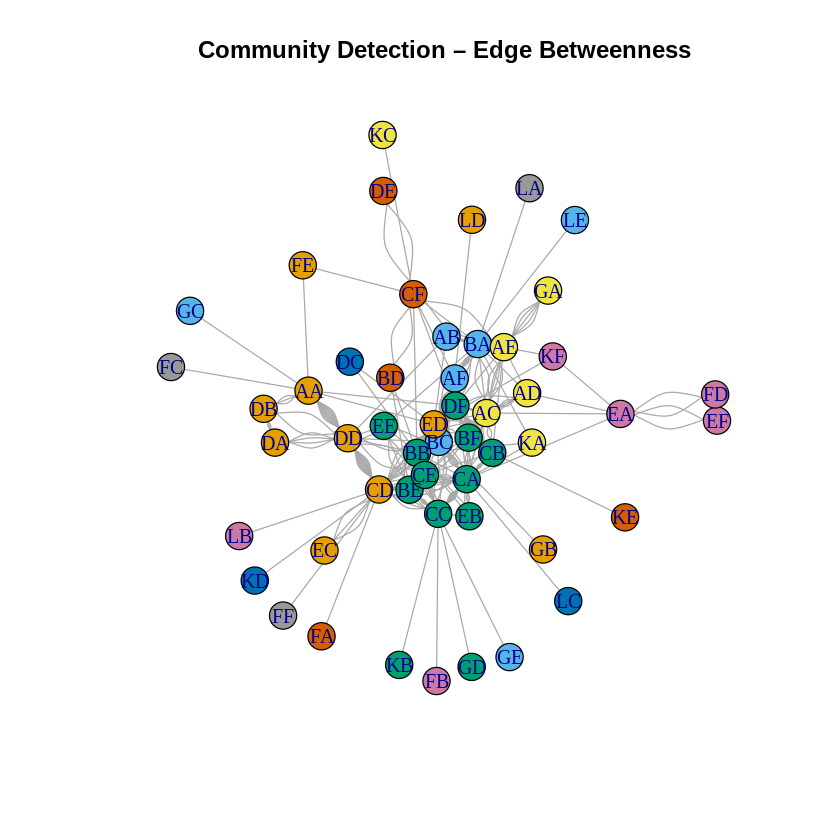

In [76]:
set.seed(123)

plot(
  community_net,
  vertex.color = membership(cnet),
  vertex.label = V(community_net)$name,
  vertex.size = 10,
  edge.arrow.size = 0.2,
  layout = layout.fruchterman.reingold,
  main = "Community Detection – Edge Betweenness"
)

In [77]:
community_table <- data.frame(
  Node = names(membership(cnet)),
  Community = as.numeric(membership(cnet))
)

community_table[
  order(community_table$Community),
]

,Node,Community
,<chr>,<dbl>
1,AA,1
4,DD,1
5,CD,1
10,ED,1
19,DB,1
36,DA,1
37,EC,1
2,AB,2
3,AF,2


Final network summary

In [78]:
cat("====================================\n")
cat("SOCIAL NETWORK ANALYSIS SUMMARY\n")
cat("====================================\n\n")

cat("Number of Nodes:", vcount(net), "\n")
cat("Number of Edges:", ecount(net), "\n")
cat("Network Diameter:", diameter(net, directed = FALSE, weights = NA), "\n")
cat("Edge Density:", edge_density(net, loops = FALSE), "\n")
cat("Reciprocity:", reciprocity(net), "\n")
cat("Number of Communities:", length(unique(membership(cnet))), "\n\n")

cat("Most Connected Node:",
    names(which.max(degree(net, mode = "all"))), "\n")

cat("Highest In-Degree Node:",
    names(which.max(degree(net, mode = "in"))), "\n")

cat("Highest Out-Degree Node:",
    names(which.max(degree(net, mode = "out"))), "\n")

cat("Top Hub:",
    names(which.max(hs)), "\n")

cat("Top Authority:",
    names(which.max(auth)), "\n")

cat("Highest Betweenness Node:",
    names(which.max(betweenness(net, directed = TRUE, weights = NA))),
    "\n")

cat("====================================\n")

SOCIAL NETWORK ANALYSIS SUMMARY

Number of Nodes: 52 
Number of Edges: 290 
Network Diameter: 5 
Edge Density: 0.1093514 
Reciprocity: 0.2965517 
Number of Communities: 26 

Most Connected Node: CA 
Highest In-Degree Node: CA 
Highest Out-Degree Node: CD 
Top Hub: CC 
Top Authority: CA 
Highest Betweenness Node: CD 


### Detailed Interpretation of Results

**Network Overview:**
*   The network consists of **52 nodes** and **290 edges**, indicating a moderately sized network of interactions.
*   The **Network Diameter is 5**, meaning the longest shortest path between any two nodes in the network is 5 steps. This suggests a relatively compact network where information can travel efficiently.
*   The **Edge Density is approximately 0.109**, indicating that about 10.9% of all possible connections exist in this network. This is a sparse network, which is common in many real-world social networks.
*   The **Reciprocity is approximately 0.297**, meaning about 29.7% of connections are reciprocated (if A links to B, B also links to A). This suggests a moderate level of mutual relationships within the network, but also a significant number of one-way interactions.

**Node Importance (Centrality Measures):**
*   **Degree Centrality:**
    *   The **Most Connected Node is 'CA' with a degree of 62**, highlighting it as a major connector in the network.
    *   **'CA' also has the highest In-Degree (50)**, indicating it is the most sought-after or referenced node, receiving many incoming connections.
    *   **'CD' has the highest Out-Degree (25)**, suggesting it is a significant initiator of connections or information flow.
*   **Closeness Centrality:**
    *   **'ED' has the highest Closeness Centrality (approximately 0.0106)**. This means 'ED' is, on average, closest to all other nodes in the network, making it efficient for spreading information.
*   **Betweenness Centrality:**
    *   **'CD' has the highest Betweenness Centrality (approximately 375.99)**. This node acts as a crucial bridge or gatekeeper, lying on many shortest paths between other pairs of nodes. Its removal could significantly impact network connectivity.
*   **Hub and Authority Scores (HITS Algorithm):**
    *   **'CC' is identified as the Top Hub (Hub Score: 1)**. Hubs are nodes that point to many authorities, suggesting 'CC' is a good directory or resource of authoritative information.
    *   **'CA' is identified as the Top Authority (Authority Score: 1)**. Authorities are nodes that are pointed to by many hubs, indicating 'CA' is a source of high-quality information or influence.

**Community Detection:**
*   The community detection analysis identified **26 distinct communities** within the network. This suggests the presence of multiple smaller, cohesive groups or clusters.
*   The **Community Modularity is approximately 0.351**. Modularity is a measure of the strength of division of a network into modules (communities). A value of 0.351 indicates a reasonably good community structure, meaning nodes within the same community are more densely connected to each other than to nodes in other communities. The plot further visualizes these distinct groups.

In summary, the network exhibits characteristics of a distributed social structure with key influential nodes ('CA', 'CD', 'CC', 'ED') acting as central connectors, information sources, or critical intermediaries. The presence of multiple communities further suggests a diverse group dynamic within the overall network.

## Conclusion

The Social Network Analysis was successfully implemented using R and the
network dataset provided with the prescribed tutorial.

The relationship data was represented using nodes and directed edges. The
network was analyzed using degree, in-degree, out-degree, density,
reciprocity, closeness, betweenness, hub and authority scores. Network
visualizations were generated to understand connectivity and node
importance.

Community detection was also performed to identify groups within the
network. The analysis successfully demonstrated how R can be used to
represent, analyze, visualize, and interpret social network structures.